# net7: what would grid cells vs non-grid cells look like on a 1D VR-style track?

Simulates a single random straight 200cm "slice" through net7's 2D open-field
arena (RNN trained purely by path integration; `data/rnn_xgboost/survey_s7_Ng1024`,
Ng=1024, rnn_seed=5555, pc_seed=55, 465/1024 units grid_score>0.3 -- the
canonical net7 used throughout this repo's two-network coupling analyses and
matching `two_network_diffPC_validation.pdf`), repeated over 100 trials with a
teleport-back-to-start reset each trial (mirroring the real VR linear-track
paradigm), and reads out unit activity along the way. Output format (bs=2cm,
tl=200cm trial-concatenated tuning curves) matches
`compute_vr_tcs`/`spectral_analysis` used for the real biological VR data, so
plots here are directly comparable to real grid/non-grid cell VR recordings.

**Exploratory** — model-generated predictions to compare against real
biological grid/non-grid cell VR recordings, not a claim about real data.

In [1]:
"""
Load the CANONICAL net7 grid-cell RNN -- data/rnn_xgboost/survey_s7_Ng1024
(rnn_seed=5555, pc_seed=55, 50k steps; Ng=1024, 465/1024 units grid_score>0.3,
median grid score 0.27, decode err 9.9cm; matches
scripts/figures/figure_validations/two_network_diffPC_validation.pdf and the
dozens of two-network coupling scripts across this repo that use it).

NOTE: an earlier version of this notebook used
data/rnn_xgboost/merge_source_net7seed_Ng1024 instead -- same rnn_seed=5555,
but a DIFFERENT pc_seed=8001 and only 25k training steps (from
run_known_good_seeds.sh), giving a materially different, weaker net (only 140
grid units). Both got casually called "net7"; survey_s7_Ng1024 is the one
actually used everywhere else in this project, so that's the one to use here.
"""
import sys, os
REPO_DIR = '/Users/harryclark/Documents/spatial-manifolds/GRID-PATTERN-FORMATION'
sys.path.insert(0, REPO_DIR)
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')
import numpy as np
import torch
from place_cells import PlaceCells
from model import RNN
from trajectory_generator import TrajectoryGenerator
from visualize import compute_ratemaps

DEVICE = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
NET_DIR = '/Users/harryclark/Documents/spatial-manifolds/data/rnn_xgboost/survey_s7_Ng1024'
CACHE_DIR = '/Users/harryclark/Documents/spatial-manifolds/data/rnn_xgboost/net7_1D_track_sim'
os.makedirs(CACHE_DIR, exist_ok=True)

class Options: pass
o = Options()
o.Np = 512; o.Ng = 1024; o.sequence_length = 20; o.batch_size = 200
o.learning_rate = 1e-4; o.weight_decay = 1e-4; o.place_cell_rf = 0.12; o.surround_scale = 2
o.pc_rf_seed = 55
o.RNN_type = 'RNN'; o.activation = 'relu'; o.DoG = True; o.periodic = False
o.box_width = 2.2; o.box_height = 2.2; o.device = DEVICE

pc = PlaceCells(o)
pc.us = torch.tensor(np.load(os.path.join(NET_DIR, 'place_cells.npy')), dtype=torch.float32).to(DEVICE)

model = RNN(o, pc).to(DEVICE)
model.load_state_dict(torch.load(os.path.join(NET_DIR, 'ckpt.pth'), map_location=DEVICE)['model'])
model.eval()
tg = TrajectoryGenerator(o, pc)

scores_npz = np.load(os.path.join(NET_DIR, 'multiscale_scores.npz'))
grid_scores = scores_npz['grid_scores']
spacings = scores_npz['spacings']
GC_THRESH = 0.3
print(f'net7: device={DEVICE}, Ng={o.Ng}, {(grid_scores>GC_THRESH).sum()} grid units '
      f'(score>{GC_THRESH}), spacing range {np.nanmin(spacings[grid_scores>GC_THRESH]):.0f}-'
      f'{np.nanmax(spacings[grid_scores>GC_THRESH]):.0f} cm')


net7: device=mps, Ng=1024, 465 grid units (score>0.3), spacing range 81-143 cm


In [2]:
"""
Manually choose a straight LEFT-TO-RIGHT (horizontal) 200cm slice through the
RNN's 2.2x2.2m box (rather than a random chord): scans candidate horizontal
lines (fixed heading=0deg, varying y) and picks the one that crosses the most
firing fields (closest to 3) for the top grid_score-scoring units, using their
open-field rate maps (computed fresh here via compute_ratemaps -- independent
of the VR simulation below). Then simulates N_TRIALS repeated runs along that
fixed line -- each trial starts fresh at the line's start point (hidden state
re-anchored via a place-cell initial activation, exactly as at the start of
every training sequence), runs to the far end, and is then "teleported" back
to the start for the next trial -- mirroring the real VR linear-track paradigm
(fixed track, teleport-reset at the end of each trial). Per-step forward speed
is drawn from the same Rayleigh distribution TrajectoryGenerator uses during
training (dt=0.02s, b=0.13*2*pi), just with heading pinned to the slice
direction instead of doing a random walk -- this keeps the network's input
statistics in-distribution while forcing a straight 1D path. Unit activity
(net7's Ng=1024 hidden units) is read out at every step and binned into 2cm
position bins (matching the real VR bs=2,tl=200 convention) so downstream
analysis/plotting can reuse the same tuning-curve format as the real
biological VR pipeline (compute_vr_tcs / spectral_analysis).
"""
from scipy.signal import find_peaks

TRACK_LEN = 2.0     # m (=200cm, matches real VR track length)
N_TRIALS = 100
BS_CM, TL_CM = 2.0, 200.0
N_BINS = int(TL_CM / BS_CM)
dt = 0.02
b_speed = 0.13 * 2 * np.pi  # forward-speed Rayleigh scale, matches TrajectoryGenerator training distribution

# ── pick a horizontal (left-to-right) slice that crosses ~3 fields ──────────
GC_THRESH = 0.3
_order = np.where(grid_scores > GC_THRESH)[0]
_order = _order[np.argsort(grid_scores[_order])[::-1]]
_slice_candidates = _order[:4]   # same top-4-by-score units shown as examples later

RES = 40
hw = o.box_width / 2
_cand_ratemaps, _, _, _ = compute_ratemaps(model, tg, o, res=RES, n_avg=50, Ng=len(_slice_candidates),
                                            idxs=np.array(_slice_candidates))

best_y_bin, best_score = RES // 2, -1
for y_bin in range(2, RES - 2):
    n_peaks_list = []
    for i in range(len(_slice_candidates)):
        profile = _cand_ratemaps[i, :, y_bin]
        peaks, _ = find_peaks(profile, height=profile.max() * 0.3, distance=3)
        n_peaks_list.append(len(peaks))
    n_match3 = sum(1 for n in n_peaks_list if n == 3)
    avg_dist_from_3 = np.mean([abs(n - 3) for n in n_peaks_list])
    score = n_match3 - 0.1 * avg_dist_from_3
    if score > best_score:
        best_score, best_y_bin = score, y_bin

y0 = (best_y_bin / RES - 0.5) * o.box_width
start_pos = np.array([-TRACK_LEN / 2, y0])
end_pos = np.array([TRACK_LEN / 2, y0])
theta = 0.0
heading_vec = np.array([np.cos(theta), np.sin(theta)])
_final_n_peaks = [len(find_peaks(_cand_ratemaps[i, :, best_y_bin],
                                  height=_cand_ratemaps[i, :, best_y_bin].max()*0.3, distance=3)[0])
                   for i in range(len(_slice_candidates))]
print(f'slice (manual, left-to-right): y={y0:.2f}m, start=({start_pos[0]:.2f},{start_pos[1]:.2f})m, '
      f'end=({end_pos[0]:.2f},{end_pos[1]:.2f})m -- fields crossed per top grid unit: {_final_n_peaks}')

all_unit_tc = np.full((o.Ng, N_TRIALS, N_BINS), np.nan, dtype=np.float32)
example_trial_xy = None
decode_errs = []

rng = np.random.RandomState(0)
torch.manual_seed(1); np.random.seed(1)
with torch.no_grad():
    for trial in range(N_TRIALS):
        dists, steps, cum = [0.0], [], 0.0
        while cum < TRACK_LEN:
            v = rng.rayleigh(b_speed)
            step = v * dt
            if cum + step > TRACK_LEN:
                step = TRACK_LEN - cum
            steps.append(step); cum += step; dists.append(cum)
        steps = np.array(steps, dtype=np.float32)
        cum_dists = np.array(dists[1:], dtype=np.float32)

        v_input = np.stack([steps*heading_vec[0], steps*heading_vec[1]], axis=-1)
        v_t = torch.tensor(v_input, dtype=torch.float32)[:, None, :].to(DEVICE)
        p0_pos = torch.tensor(start_pos, dtype=torch.float32)[None, None, :].to(DEVICE)
        ia = pc.get_activation(p0_pos).squeeze(0)

        g = model.g((v_t, ia))
        g_np = g.squeeze(1).cpu().numpy()

        preds = model.predict((v_t, ia))
        pred_xy = pc.get_nearest_cell_pos(preds).squeeze(1).cpu().numpy()
        true_xy = start_pos[None, :] + cum_dists[:, None]*heading_vec[None, :]
        decode_errs.append(np.linalg.norm(pred_xy - true_xy, axis=1))

        pos_cm = cum_dists * 100.0
        bin_idx = np.clip((pos_cm / BS_CM).astype(int), 0, N_BINS-1)
        for b_i in range(N_BINS):
            sel = bin_idx == b_i
            if sel.any():
                all_unit_tc[:, trial, b_i] = g_np[sel].mean(axis=0)

        if trial == 0:
            example_trial_xy = start_pos[None, :] + np.cumsum(v_input, axis=0)

decode_errs = np.concatenate(decode_errs)
print(f'{N_TRIALS} trials simulated, mean decode err={decode_errs.mean()*100:.2f}cm '
      f'(vs {scores_npz["err_cm"]:.1f}cm at training), nan bin fraction={np.isnan(all_unit_tc).mean():.1%}')

np.savez(os.path.join(CACHE_DIR, 'sim_cache.npz'),
         all_unit_tc=all_unit_tc, grid_scores=grid_scores, spacings=spacings,
         start_pos=start_pos, end_pos=end_pos, theta=theta,
         example_trial_xy=example_trial_xy, box_width=o.box_width,
         bs=BS_CM, tl=TL_CM, n_trials=N_TRIALS)
print(f'cached -> {CACHE_DIR}/sim_cache.npz')


slice (manual, left-to-right): y=-0.11m, start=(-1.00,-0.11)m, end=(1.00,-0.11)m -- fields crossed per top grid unit: [1, 3, 3, 3]


100 trials simulated, mean decode err=6.83cm (vs 9.9cm at training), nan bin fraction=22.0%
cached -> /Users/harryclark/Documents/spatial-manifolds/data/rnn_xgboost/net7_1D_track_sim/sim_cache.npz


In [3]:
"""
Select example grid units (the top grid_score-scoring units) and example
non-grid units (|grid_score| near zero) to compare directly.
"""
d = np.load(os.path.join(CACHE_DIR, 'sim_cache.npz'))
all_unit_tc = d['all_unit_tc']
grid_scores = d['grid_scores']; spacings = d['spacings']
start_pos, end_pos, theta = d['start_pos'], d['end_pos'], float(d['theta'])
example_trial_xy = d['example_trial_xy']
BS, TL, N_TRIALS = float(d['bs']), float(d['tl']), int(d['n_trials'])
box_width = float(d['box_width'])

GC_THRESH = 0.3
grid_idx = np.where(grid_scores > GC_THRESH)[0]
nongrid_idx = np.where(np.abs(grid_scores) < 0.05)[0]

# top 4 grid units by grid_score
order = grid_idx[np.argsort(grid_scores[grid_idx])[::-1]]
grid_examples = order[:4]

rng2 = np.random.RandomState(2)
nongrid_examples = rng2.choice(nongrid_idx, size=4, replace=False)
nongrid_examples.sort()

print('grid examples (unit: score, spacing_cm):')
for u in grid_examples:
    print(f'  {u}: gs={grid_scores[u]:.2f}, spacing={spacings[u]:.1f}cm')
print('non-grid examples (unit: score):')
for u in nongrid_examples:
    print(f'  {u}: gs={grid_scores[u]:.3f}')


grid examples (unit: score, spacing_cm):
  318: gs=1.06, spacing=95.9cm
  290: gs=1.04, spacing=91.0cm
  23: gs=1.02, spacing=96.0cm
  596: gs=1.01, spacing=94.1cm
non-grid examples (unit: score):
  273: gs=0.032
  325: gs=0.008
  550: gs=-0.022
  883: gs=0.004


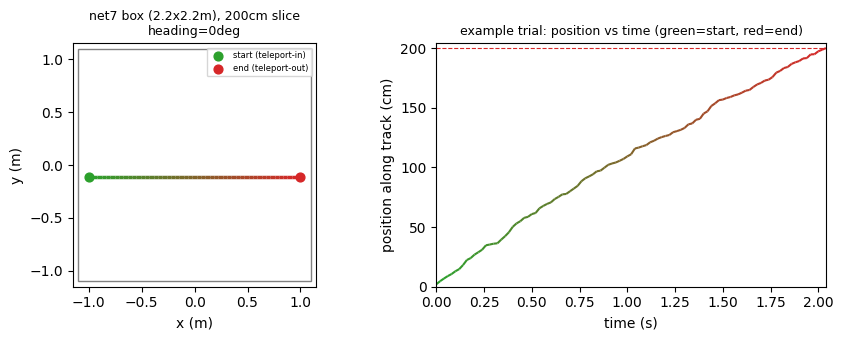

In [4]:
"""Behaviour plot: the chosen slice through the box, and one example trial's
simulated running trajectory along it. Paths are color-coded from start
(green) to end (red) so trajectory direction is visible at a glance."""
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap

START_END_CMAP = LinearSegmentedColormap.from_list('start_end', ['tab:green', 'tab:red'])

def plot_gradient_path(ax, xy, cmap=START_END_CMAP, linewidth=1.5, zorder=2, alpha=1.0):
    """Draws xy (N,2) as a line whose color gradually shifts from cmap(0) at
    the start to cmap(1) at the end."""
    points = xy.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=cmap, array=np.linspace(0, 1, len(segments)),
                         linewidth=linewidth, zorder=zorder, alpha=alpha)
    ax.add_collection(lc)
    return lc

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

ax = axes[0]
hw = box_width / 2
ax.add_patch(plt.Rectangle((-hw, -hw), box_width, box_width, fill=False, edgecolor='grey', linewidth=1))
plot_gradient_path(ax, np.linspace(start_pos, end_pos, 50), linewidth=2.5, zorder=3)
plot_gradient_path(ax, example_trial_xy, linewidth=0.8, zorder=2, alpha=0.8)
ax.scatter(*start_pos, color='tab:green', s=40, zorder=4, label='start (teleport-in)')
ax.scatter(*end_pos, color='tab:red', s=40, zorder=4, label='end (teleport-out)')
ax.set_xlim(-hw-0.05, hw+0.05); ax.set_ylim(-hw-0.05, hw+0.05)
ax.set_aspect('equal')
ax.set_title(f'net7 box (2.2x2.2m), 200cm slice\nheading={np.degrees(theta):.0f}deg', fontsize=9)
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.legend(fontsize=6, loc='upper right')

ax = axes[1]
along_track_cm = np.linalg.norm(example_trial_xy - start_pos[None, :], axis=1) * 100
t_axis = np.arange(len(along_track_cm)) * dt
points = np.stack([t_axis, along_track_cm], axis=1)
plot_gradient_path(ax, points, linewidth=1.5, zorder=2)
ax.set_xlim(t_axis.min(), t_axis.max()); ax.set_ylim(0, max(along_track_cm.max(), 200)*1.02)
ax.set_xlabel('time (s)'); ax.set_ylabel('position along track (cm)')
ax.set_title('example trial: position vs time (green=start, red=end)', fontsize=9)
ax.axhline(200, color='tab:red', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, 'behaviour.pdf'), bbox_inches='tight', dpi=200)
plt.show()


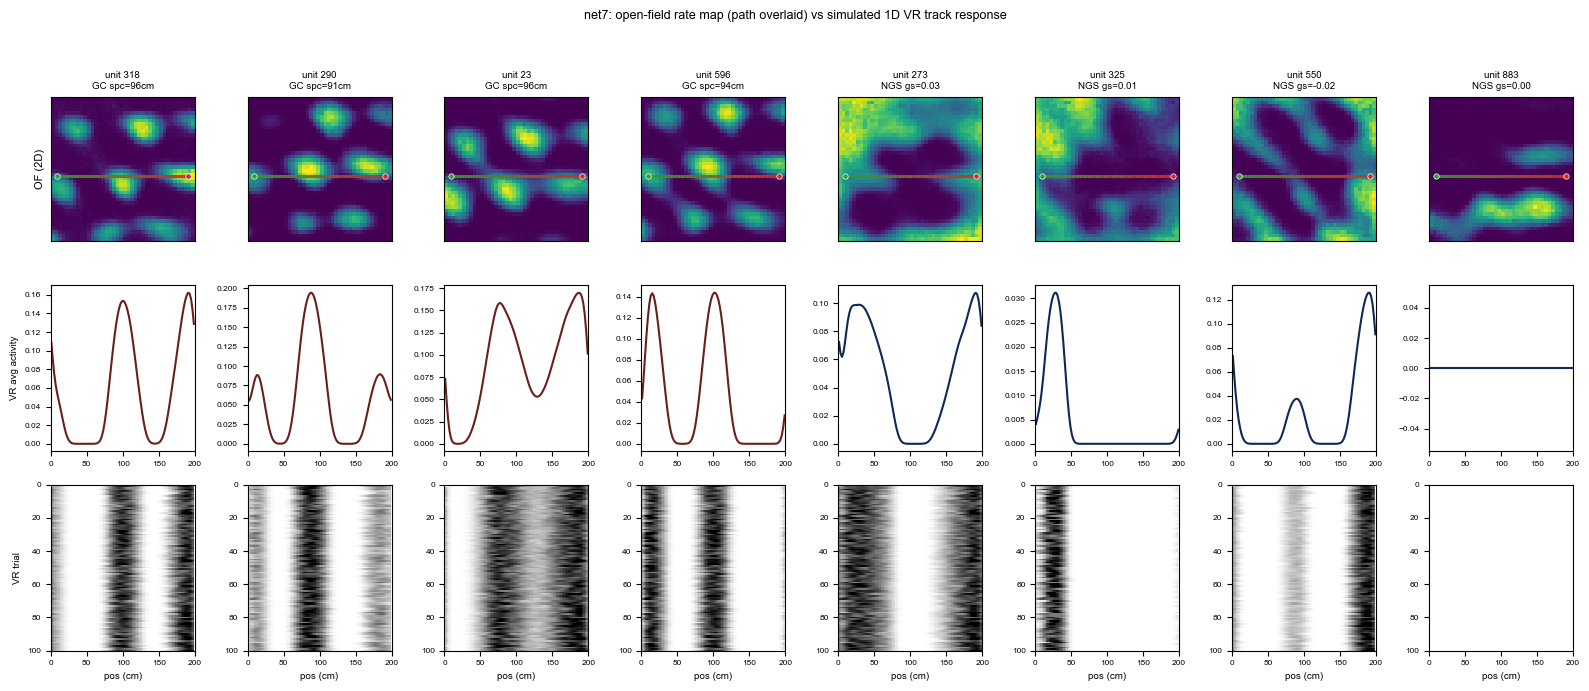

In [5]:
"""
Open-field 2D rate map (with the simulated 200cm path overlaid) alongside the
1D 'VR-style' rate map (trial-averaged profile + trial x position raster), for
the example grid units vs non-grid units -- so you can see directly how the 2D
grid pattern translates into the 1D response along this particular slice.

The 1D avg-profile x-axis uses get_avg_profile (proper cm units) rather than
plot_avg_firing_rate_map's own x-axis (which plots raw bin index 0..99, not
cm -- that's why it looked like it stopped at "100" before: bs=2cm so 100 bins
covers the full 200cm, but the function's x-axis was never converted to cm).
"""
from scipy.ndimage import gaussian_filter
from spatial_manifolds.behaviour_plots import plot_firing_rate_map
from spatial_manifolds.detect_grids import get_avg_profile

RES = 40
units = list(grid_examples) + list(nongrid_examples)
labels = [f'GC spc={spacings[u]:.0f}cm' for u in grid_examples] + [f'NGS gs={grid_scores[u]:.2f}' for u in nongrid_examples]
colors = ['#69201a']*len(grid_examples) + ['#0d2958']*len(nongrid_examples)

of_ratemaps, _, _, _ = compute_ratemaps(model, tg, o, res=RES, n_avg=50, Ng=len(units), idxs=np.array(units))

fig, axes = plt.subplots(3, len(units), figsize=(2.0*len(units), 7))
hw = box_width / 2
for i, (u, lab, c) in enumerate(zip(units, labels, colors)):
    ax_of = axes[0, i]
    ax_of.imshow(of_ratemaps[i].T, origin='lower', extent=[-hw, hw, -hw, hw], cmap='viridis')
    plot_gradient_path(ax_of, np.linspace(start_pos, end_pos, 50), linewidth=2.2, zorder=3)
    ax_of.scatter(*start_pos, color='tab:green', s=15, zorder=4, edgecolor='white', linewidth=0.5)
    ax_of.scatter(*end_pos, color='tab:red', s=15, zorder=4, edgecolor='white', linewidth=0.5)
    ax_of.set_xticks([]); ax_of.set_yticks([])
    ax_of.set_title(f'unit {u}\n{lab}', fontsize=7)

    tc = all_unit_tc[u].ravel()
    tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
    x, y = get_avg_profile(tc, bs=BS, tl=TL)
    axes[1, i].plot(x, y, color=c)
    axes[1, i].set_xlim(0, TL)
    plot_firing_rate_map(axes[2, i], tc, bs=BS, tl=TL, cmap='binary')
    axes[2, i].set_xlabel('pos (cm)', fontsize=7)
    axes[1, i].tick_params(labelsize=6); axes[2, i].tick_params(labelsize=6)
axes[0, 0].set_ylabel('OF (2D)', fontsize=8)
axes[1, 0].set_ylabel('VR avg activity', fontsize=7)
axes[2, 0].set_ylabel('VR trial', fontsize=7)
fig.suptitle('net7: open-field rate map (path overlaid) vs simulated 1D VR track response', fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(CACHE_DIR, 'ratemaps_OF_vs_VR.pdf'), bbox_inches='tight', dpi=200)
plt.show()


grid group: 92.6% of spectrogram windows track-length-anchored (n=20 cells)
non-grid group: 84.3% of spectrogram windows track-length-anchored (n=20 cells)


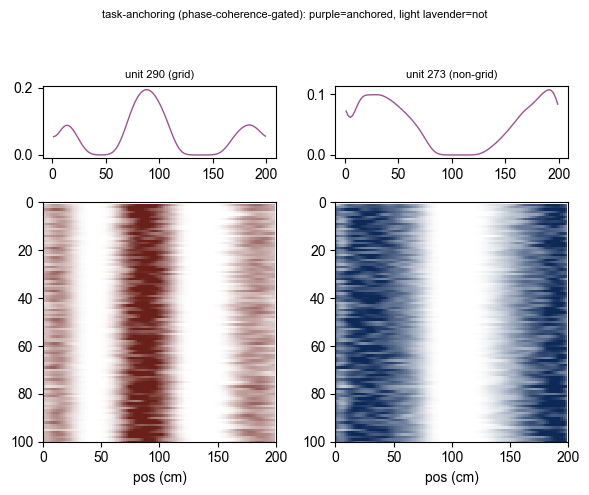

In [6]:
"""
Task-anchored (trial/track-boundary-locked) spectral analysis, computed PER
CELL, extending scripts/figures/figure_6_task_anchoring/example_multshank_reconstruction.ipynb's
method (tc NaN-filled + gaussian-smoothed before spectral analysis, duplicate
self-entry so spectral_analysis's internal clustering machinery doesn't
degenerate on a single cell, peak_indices=[12,28,44,60,76] = harmonics of the
200cm track) with a PHASE-COHERENCE GATE (local to this notebook, not the
shared library) on top.

Why the gate: raw spectral power at a harmonic bin cannot tell "trial-locked,
phase-consistent firing" (genuine anchoring) apart from "still periodically
modulated at that frequency, but with a DIFFERENT, effectively random phase
each trial" (not anchored at all -- just a cell whose intrinsic spacing
happens to be close to a harmonic period). Investigation of the A->C->A
switching session showed exactly this: during the blind (C) phase, many
trials keep firing robustly (not silent) but with phase scattered across the
full circle trial-to-trial, while spectral power at the harmonic bin stayed
high throughout -- producing a spurious ~15-trial-long false "anchored" tail
that the ground truth (decode error, raw per-trial correlation) does not
show at all (those transition in a single trial). The gate: for a window
whose peak power lands on a harmonic bin, extract each trial's phase at that
frequency (matched-filter: angle of sum(profile * exp(-2pi*i*x/period)),
skipping trials with negligible modulation strength), then require the
circular resultant length R across the window's trials to exceed
PHASE_COHERENCE_THRESH before accepting the window as anchored.

Colors: purple (#9d5391)=task-anchored(1), light lavender (#5f9ea0)=not(0)
(matches figure_6_task_anchoring/task_anchoring_schematic.ipynb).
"""
from spatial_manifolds.toroidal import spectral_analysis
from spatial_manifolds.detect_grids import get_kmeans_spatial_labels, get_avg_profile, white_to_hex_cmap
from spatial_manifolds.behaviour_plots import plot_firing_rate_map
from scipy.ndimage import gaussian_filter
from matplotlib.colors import ListedColormap, BoundaryNorm

PEAK_INDICES = [12, 28, 44, 60, 76]
PERIOD_CM = {12: 100.0, 28: 50.0, 44: 200/6, 60: 25.0, 76: 20.0}
NPERSEG, NOVERLAP = 1600, 1400
WIN_STEP = NPERSEG - NOVERLAP
PHASE_COHERENCE_THRESH = 0.5
MIN_TRIALS_FOR_PHASE = 4
MIN_MOD_STRENGTH = 0.05
TA_CMAP = ListedColormap(["#5f9ea0", "#9d5391"])
TA_NORM = BoundaryNorm([-0.5, 0.5, 1.5], TA_CMAP.N)

def _window_phase_coherence(raw_trials, start_trial, end_trial, period_cm, bin_pos_cm):
    phases = []
    for t in range(start_trial, min(end_trial, raw_trials.shape[0])):
        row = raw_trials[t]
        total = np.nansum(np.abs(row))
        if total < 1e-9:
            continue
        z = np.nansum(row * np.exp(-2j * np.pi * bin_pos_cm / period_cm))
        if np.abs(z) / total >= MIN_MOD_STRENGTH:
            phases.append(np.angle(z))
    if len(phases) < MIN_TRIALS_FOR_PHASE:
        return np.nan
    return np.abs(np.mean(np.exp(1j * np.array(phases))))

def per_cell_task_anchored(tc_array, unit_id):
    """Returns (window_labels, trial_labels, smoothed_tc). NaN-safe: some
    degenerate (near-flat) units make spectral_analysis's internal peak-finding
    fail on a handful of windows (a pre-existing edge case in toroidal.py,
    unrelated to this fix) -- caught and reported as NaN rather than crashing."""
    raw_trials = tc_array[unit_id]
    tc = gaussian_filter(np.nan_to_num(raw_trials.ravel()).astype(np.float64), sigma=2.5)
    tcs_to_use = {int(unit_id): tc, 1000: tc}
    try:
        results = spectral_analysis(tcs_to_use, TL, bs=BS)
    except Exception:
        return None, None, tc
    S = results[3].mean(0)
    max_peaks = np.argmax(S, axis=0)
    raw_window_labels = np.isin(max_peaks, PEAK_INDICES)

    bpt = int(TL / BS)
    bin_pos_cm = (np.arange(raw_trials.shape[1]) + 0.5) * BS
    window_labels = np.zeros(len(raw_window_labels), dtype=int)
    for i in range(len(raw_window_labels)):
        if not raw_window_labels[i] or max_peaks[i] not in PERIOD_CM:
            continue
        start_trial, end_trial = (i * WIN_STEP) // bpt, (i * WIN_STEP + NPERSEG) // bpt
        R = _window_phase_coherence(raw_trials, start_trial, end_trial, PERIOD_CM[max_peaks[i]], bin_pos_cm)
        window_labels[i] = int(R > PHASE_COHERENCE_THRESH) if not np.isnan(R) else 0

    trial_labels = get_kmeans_spatial_labels(tc, window_labels, bs=BS, tl=TL)
    return window_labels, trial_labels, tc

def group_mean_anchored_arr(tc_arr, idxs, n=20):
    fracs = []
    for u in idxs[:n]:
        wl, _, _ = per_cell_task_anchored(tc_arr, int(u))
        if wl is not None:
            fracs.append(wl.mean())
    return np.nanmean(fracs), len(fracs)

grid_mean, n1 = group_mean_anchored_arr(all_unit_tc, grid_idx)
nongrid_mean, n2 = group_mean_anchored_arr(all_unit_tc, nongrid_idx)
print(f'grid group: {grid_mean:.1%} of spectrogram windows track-length-anchored (n={n1} cells)')
print(f'non-grid group: {nongrid_mean:.1%} of spectrogram windows track-length-anchored (n={n2} cells)')

# composite plot: trial-by-position raster + task-anchored/not raster below it +
# per-group avg profile, for one example grid and one example non-grid unit.
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(6, 5), height_ratios=[0.3, 1])
for col, (u, title, cmap) in enumerate([
    (grid_examples[1], 'grid', white_to_hex_cmap('#69201a')),
    (nongrid_examples[0], 'non-grid', white_to_hex_cmap('#0d2958')),
]):
    window_labels, trial_labels, tc = per_cell_task_anchored(all_unit_tc, u)
    ax_avg, ax_raster = axes[0, col], axes[1, col]
    plot_firing_rate_map(ax_raster, tc, bs=BS, tl=TL, p=95, cmap=cmap)
    ax_raster.set_xlabel('pos (cm)')
    ax_avg.set_title(f'unit {u} ({title})', fontsize=8)
    for label_val, plot_color in zip([1, 0], ['#9d5391', '#5f9ea0']):
        mask = trial_labels == label_val
        if mask.sum() > 5:
            x, y = get_avg_profile(tc, BS, TL, mask=mask)
            ax_avg.plot(x, y, color=plot_color, linewidth=1)
    raster_row = np.expand_dims(trial_labels, axis=0)
    xlim, ylim = ax_raster.get_xlim(), ax_raster.get_ylim()
    ax_raster.imshow(raster_row, aspect='auto', cmap=TA_CMAP, norm=TA_NORM, interpolation='none',
                      extent=[*xlim, ylim[0] - 0.15*(ylim[1]-ylim[0]), ylim[0]])
fig.suptitle('task-anchoring (phase-coherence-gated): purple=anchored, light lavender=not', fontsize=8)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(os.path.join(CACHE_DIR, 'task_anchoring.pdf'), bbox_inches='tight', dpi=200)
plt.show()


A: teleport + cue (baseline): grid 93.3% anchored, non-grid 91.9% anchored


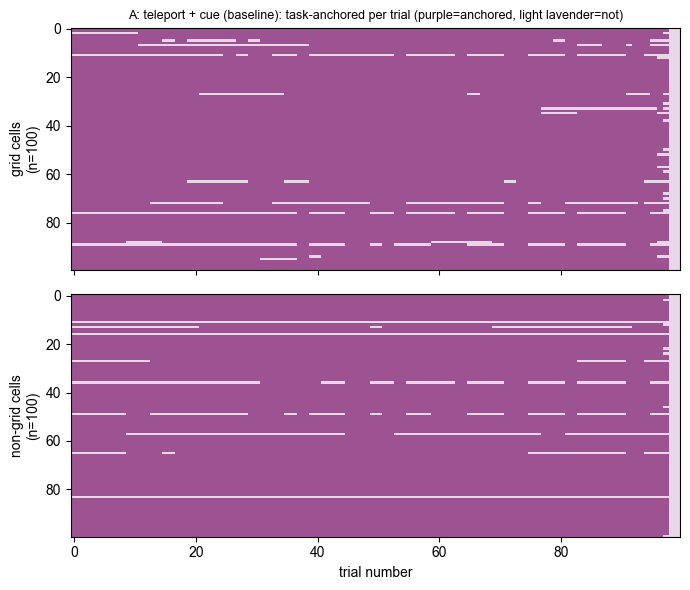

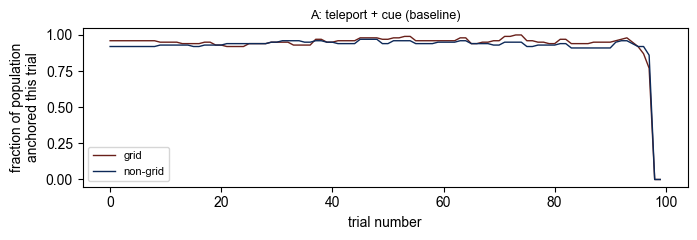

In [7]:
"""
Population-level view: task-anchored (purple) vs not (light lavender) trial labels for
every sampled grid cell and non-grid cell, stacked as a raster (rows=cells,
columns=trials) -- so you can see at a glance whether cells switch between
anchored/non-anchored states across trials, and whether that switching is
shared across the population (all cells flipping together) or independent
per-cell. Same color convention as the schematic
(figure_6_task_anchoring/task_anchoring_schematic.ipynb): purple=1
(anchored), light lavender=0 (not), white=no data. Defined here as a reusable function so
it can also be applied to the B/C conditions below (where switching is much
more visible than in this near-ceiling baseline).
"""
N_POP_SAMPLE = 100  # cap per group for runtime; set to None to use all

def sample_idxs(idxs, n, seed=0):
    if n is None or len(idxs) <= n:
        return idxs
    return idxs[np.random.RandomState(seed).choice(len(idxs), size=n, replace=False)]

grid_sample = sample_idxs(grid_idx, N_POP_SAMPLE)
nongrid_sample = sample_idxs(nongrid_idx, N_POP_SAMPLE)

def trial_label_matrix(tc_arr, idxs):
    rows = []
    for u in idxs:
        _, trial_labels, _ = per_cell_task_anchored(tc_arr, int(u))
        rows.append(trial_labels if trial_labels is not None else np.full(N_TRIALS, np.nan))
    return np.array(rows)

def plot_population_raster(tc_arr, grid_ids, nongrid_ids, title, save_name):
    grid_matrix = trial_label_matrix(tc_arr, grid_ids)
    nongrid_matrix = trial_label_matrix(tc_arr, nongrid_ids)
    print(f'{title}: grid {np.nanmean(grid_matrix):.1%} anchored, '
          f'non-grid {np.nanmean(nongrid_matrix):.1%} anchored')

    fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True,
                              gridspec_kw={'height_ratios': [len(grid_ids), len(nongrid_ids)]})
    axes[0].imshow(grid_matrix, aspect='auto', cmap=TA_CMAP, norm=TA_NORM, interpolation='nearest')
    axes[0].set_ylabel(f'grid cells\n(n={len(grid_ids)})')
    axes[0].set_title(f'{title}: task-anchored per trial (purple=anchored, light lavender=not)', fontsize=9)
    axes[1].imshow(nongrid_matrix, aspect='auto', cmap=TA_CMAP, norm=TA_NORM, interpolation='nearest')
    axes[1].set_ylabel(f'non-grid cells\n(n={len(nongrid_ids)})')
    axes[1].set_xlabel('trial number')
    plt.tight_layout()
    plt.savefig(os.path.join(CACHE_DIR, f'{save_name}_raster.pdf'), bbox_inches='tight', dpi=200)
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 2.5))
    ax.plot(np.nanmean(grid_matrix, axis=0), color='#69201a', label='grid', linewidth=1)
    ax.plot(np.nanmean(nongrid_matrix, axis=0), color='#0d2958', label='non-grid', linewidth=1)
    ax.set_xlabel('trial number'); ax.set_ylabel('fraction of population\nanchored this trial')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(CACHE_DIR, f'{save_name}_timecourse.pdf'), bbox_inches='tight', dpi=200)
    plt.show()
    return grid_matrix, nongrid_matrix

grid_matrix_A, nongrid_matrix_A = plot_population_raster(
    all_unit_tc, grid_sample, nongrid_sample, 'A: teleport + cue (baseline)', 'task_anchoring_population_A')


## What conditions is track-length ("task-anchored") locking lost under?

Tests whether losing the corrective cue at a teleport is enough to destroy
track-length-locked activity, by comparing the A baseline against:

- **C. teleport, no cue**: the mouse *is* teleported back to the start every
  lap (a real discontinuity) but the network is never told -- no p0 reset,
  hidden state carries over uncorrected, and the teleport step is fed as zero
  velocity (no self-motion information at the jump).

Built from one continuous forward pass (hidden state carries over naturally,
never explicitly reset), covering the same total distance as the A baseline
(100 x 200cm).


In [8]:
"""
Build condition C: teleport happens (position resets, a real discontinuity)
but the network is never told -- no p0 reset, hidden state carries over
uncorrected, and the teleport step itself is fed as zero velocity (no
self-motion information at the jump) -- "teleport without cue". Built from
ONE continuous model.g() call (hidden state carries over naturally, never
explicitly reset), covering the same total distance as the A baseline
(100 x 200cm = 200m).
"""
N_LAPS = 100  # laps/trials, matches baseline N_TRIALS

def build_teleport_blind_condition(rng):
    """Teleport happens (position resets, a real discontinuity) but no p0
    reset and no self-motion info given at the jump (zero-velocity step)."""
    steps, lap_idx, pos_in_lap = [], [], []
    for lap in range(N_LAPS):
        cum = 0.0
        while cum < TRACK_LEN:
            v = rng.rayleigh(b_speed)
            step = v * dt
            if cum + step > TRACK_LEN:
                step = TRACK_LEN - cum
            cum += step
            steps.append(step)
            lap_idx.append(lap)
            pos_in_lap.append(cum)
        if lap < N_LAPS - 1:
            steps.append(0.0)      # blind teleport step: no velocity info given
            lap_idx.append(lap+1)  # belongs to the NEW lap at position 0
            pos_in_lap.append(0.0)
    return np.array(steps, dtype=np.float32), np.array(lap_idx), np.array(pos_in_lap, dtype=np.float32)

def run_condition(steps_1d, lap_idx, pos_in_lap, heading_vec):
    """ONE continuous forward pass -- hidden state is set via p0 exactly once
    at the very start and never reset again ('no cue at the reset')."""
    n_bins = int(TL_CM / BS_CM)
    tc = np.full((o.Ng, N_LAPS, n_bins), np.nan, dtype=np.float32)
    with torch.no_grad():
        v_input = np.stack([steps_1d*heading_vec[0], steps_1d*heading_vec[1]], axis=-1)
        v_t = torch.tensor(v_input, dtype=torch.float32)[:, None, :].to(DEVICE)
        p0_pos = torch.tensor(start_pos, dtype=torch.float32)[None, None, :].to(DEVICE)
        ia = pc.get_activation(p0_pos).squeeze(0)
        g = model.g((v_t, ia)).squeeze(1).cpu().numpy()
        bin_idx = np.clip((pos_in_lap*100/BS_CM).astype(int), 0, n_bins-1)
        for lap in range(N_LAPS):
            sel = lap_idx == lap
            for b_i in range(n_bins):
                m = sel & (bin_idx == b_i)
                if m.any():
                    tc[:, lap, b_i] = g[m].mean(axis=0)
    return tc

rng_c = np.random.RandomState(11)
steps_c, lap_c, pos_c = build_teleport_blind_condition(rng_c)
tc_teleport_blind = run_condition(steps_c, lap_c, pos_c, heading_vec)
print(f'teleport_blind: {len(steps_c)} steps, {lap_c.max()+1} laps simulated')

np.savez(os.path.join(CACHE_DIR, 'conditions_cache.npz'), tc_teleport_blind=tc_teleport_blind)
print('cached condition C')


teleport_blind: 9975 steps, 100 laps simulated
cached condition C


C: teleport, no cue: grid 0.4% anchored, non-grid 0.3% anchored


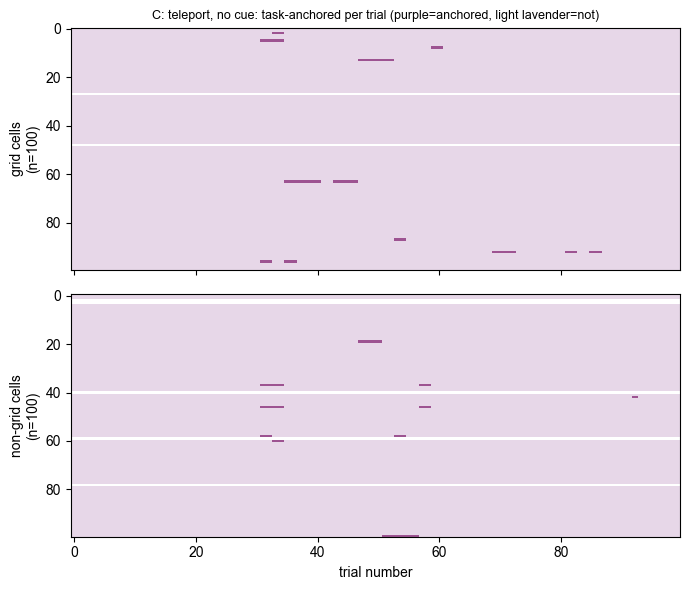

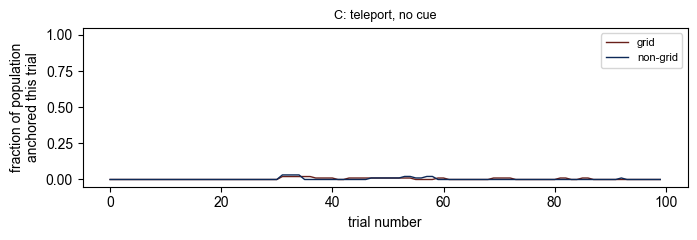

In [9]:
"""
Same population raster as above, now for condition C -- this is where
switching between anchored/non-anchored states is actually visible (the A
baseline is too close to ceiling for that). Uses the same grid_sample/
nongrid_sample cell subset as the A raster, so cells are directly comparable
across conditions.
"""
grid_matrix_C, nongrid_matrix_C = plot_population_raster(
    tc_teleport_blind, grid_sample, nongrid_sample, 'C: teleport, no cue', 'task_anchoring_population_C')


condition                       grid % anchored   non-grid % anchored 


A: teleport + cue (baseline)    92.6%             84.3%                 (n=20/20 cells scored)


C: teleport, no cue             0.7%              0.2%                  (n=20/18 cells scored)


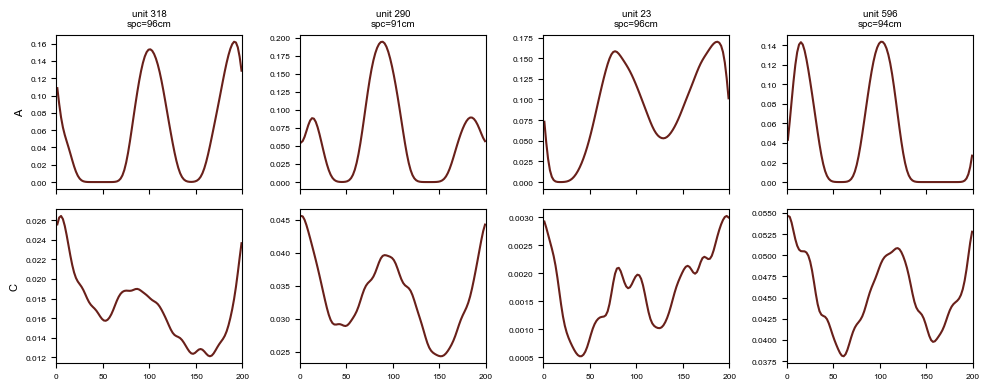

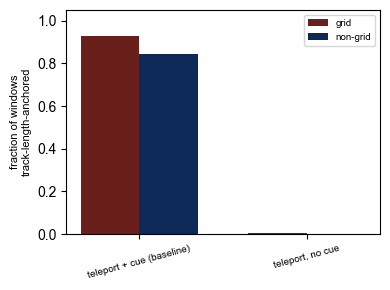

In [10]:
"""
Compare task-anchored fraction (grid group + non-grid group) between A and C,
using the corrected per-cell method from the cell above. Also sanity-check
that grid periodicity survives in C (so any difference in task-anchoring
isn't just "the network broke").
"""
conditions = {
    'A: teleport + cue (baseline)': all_unit_tc,
    'C: teleport, no cue': tc_teleport_blind,
}

print(f"{'condition':<32}{'grid % anchored':<18}{'non-grid % anchored':<20}")
summary = {}
for name, tc_arr in conditions.items():
    gm, n1 = group_mean_anchored_arr(tc_arr, grid_idx)
    nm, n2 = group_mean_anchored_arr(tc_arr, nongrid_idx)
    summary[name] = (gm, nm)
    print(f"{name:<32}{gm:<18.1%}{nm:<20.1%}  (n={n1}/{n2} cells scored)")

# sanity check: does grid periodicity (the original finding) survive in C?
fig, axes = plt.subplots(2, 4, figsize=(10, 4), sharex=True)
for row, (name, tc_arr) in enumerate(conditions.items()):
    for col, u in enumerate(grid_examples):
        tc = gaussian_filter(np.nan_to_num(tc_arr[u].ravel()).astype(np.float64), sigma=2.5)
        x, y = get_avg_profile(tc, bs=BS, tl=TL)
        axes[row, col].plot(x, y, color='#69201a')
        axes[row, col].set_xlim(0, TL)
        if row == 0:
            axes[row, col].set_title(f'unit {u}\nspc={spacings[u]:.0f}cm', fontsize=7)
        axes[row, col].tick_params(labelsize=6)
    axes[row, 0].set_ylabel(name.split(':')[0], fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, 'condition_comparison_periodicity.pdf'), bbox_inches='tight', dpi=200)
plt.show()

# bar chart summary
fig, ax = plt.subplots(figsize=(4, 3))
x = np.arange(len(conditions))
w = 0.35
grid_vals = [summary[k][0] for k in conditions]
nongrid_vals = [summary[k][1] for k in conditions]
ax.bar(x - w/2, grid_vals, width=w, color='#69201a', label='grid')
ax.bar(x + w/2, nongrid_vals, width=w, color='#0d2958', label='non-grid')
ax.set_xticks(x); ax.set_xticklabels([k.split(': ')[1] for k in conditions], fontsize=7, rotation=15)
ax.set_ylabel('fraction of windows\ntrack-length-anchored', fontsize=8)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, 'condition_comparison_summary.pdf'), bbox_inches='tight', dpi=200)
plt.show()


## Mode-switching between conditions, and the full population raster

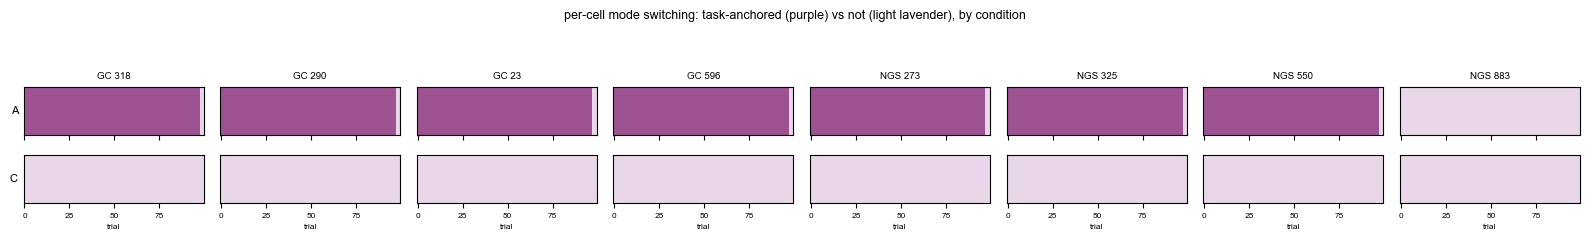

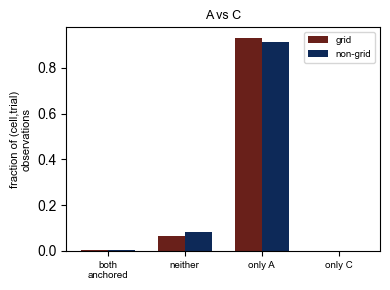

In [11]:
"""
Mode-switching between conditions A/C: for the example grid + non-grid cells,
a compact 2-row raster (rows=A,C) per cell shows exactly which trials are
anchored under each (separately simulated) condition. Below that, a
population-level summary quantifies switching between A and C as the fraction
of (cell,trial) observations that are anchored in both, neither, or only one
condition -- using the same 100-cell samples already computed above
(grid_matrix_A/C, nongrid_matrix_A/C).
"""
example_units = list(grid_examples) + list(nongrid_examples)
example_titles = [f'GC {u}' for u in grid_examples] + [f'NGS {u}' for u in nongrid_examples]

fig, axes = plt.subplots(2, len(example_units), figsize=(2.0*len(example_units), 2.4), sharex=True, sharey=True)
for col, (u, title) in enumerate(zip(example_units, example_titles)):
    for row, (name, tc_arr) in enumerate([('A', all_unit_tc), ('C', tc_teleport_blind)]):
        _, trial_labels, _ = per_cell_task_anchored(tc_arr, int(u))
        row_img = np.full((1, N_TRIALS), np.nan) if trial_labels is None else trial_labels[None, :]
        axes[row, col].imshow(row_img, aspect='auto', cmap=TA_CMAP, norm=TA_NORM, interpolation='nearest')
        axes[row, col].set_yticks([])
        if row == 0:
            axes[row, col].set_title(title, fontsize=7)
        if col == 0:
            axes[row, col].set_ylabel(name, fontsize=8, rotation=0, ha='right', va='center')
    axes[1, col].set_xlabel('trial', fontsize=6)
    axes[1, col].tick_params(labelsize=6)
fig.suptitle('per-cell mode switching: task-anchored (purple) vs not (light lavender), by condition', fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(os.path.join(CACHE_DIR, 'mode_switching_example_cells.pdf'), bbox_inches='tight', dpi=200)
plt.show()

# ── population-level A-C transition summary ──────────────────────────────
def transition_fractions(mat1, mat2):
    a = mat1.ravel(); b = mat2.ravel()
    valid = ~np.isnan(a) & ~np.isnan(b)
    a, b = a[valid], b[valid]
    both = np.mean((a == 1) & (b == 1))
    neither = np.mean((a == 0) & (b == 0))
    only1 = np.mean((a == 1) & (b == 0))
    only2 = np.mean((a == 0) & (b == 1))
    return both, neither, only1, only2

fig, ax = plt.subplots(figsize=(4, 3))
grid_fracs = transition_fractions(grid_matrix_A, grid_matrix_C)
nongrid_fracs = transition_fractions(nongrid_matrix_A, nongrid_matrix_C)
cats = ['both\nanchored', 'neither', 'only A', 'only C']
x = np.arange(4); w = 0.35
ax.bar(x - w/2, grid_fracs, width=w, color='#69201a', label='grid')
ax.bar(x + w/2, nongrid_fracs, width=w, color='#0d2958', label='non-grid')
ax.set_xticks(x); ax.set_xticklabels(cats, fontsize=7)
ax.set_ylabel('fraction of (cell,trial)\nobservations', fontsize=8)
ax.set_title('A vs C', fontsize=9)
ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, 'mode_switching_transition_summary.pdf'), bbox_inches='tight', dpi=200)
plt.show()


  A: 200/1024 units (4s)


  A: 400/1024 units (8s)


  A: 600/1024 units (13s)


  A: 800/1024 units (17s)


  A: 1000/1024 units (22s)


...

  C: 400/1024 units (5s)


  C: 600/1024 units (8s)


  C: 800/1024 units (10s)


  C: 1000/1024 units (13s)


  C: done, 13s total


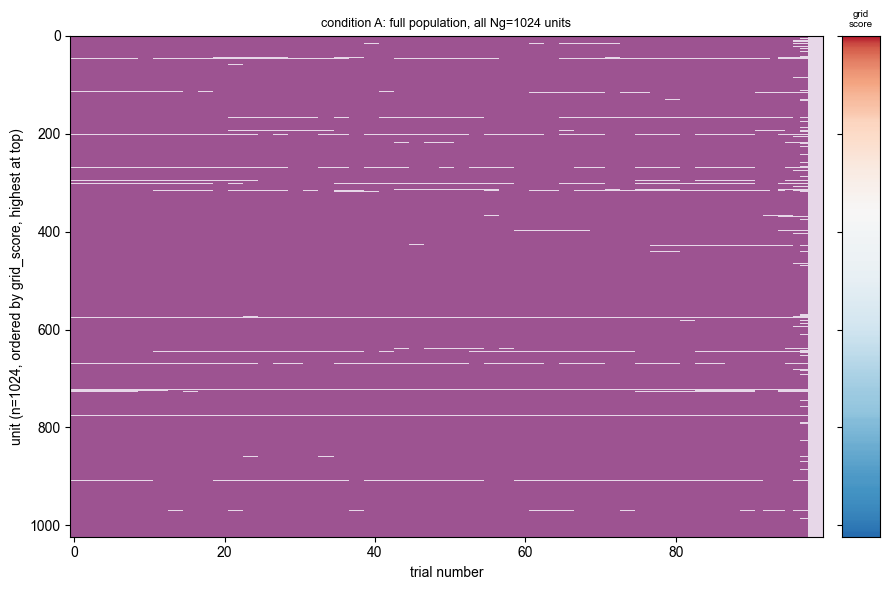

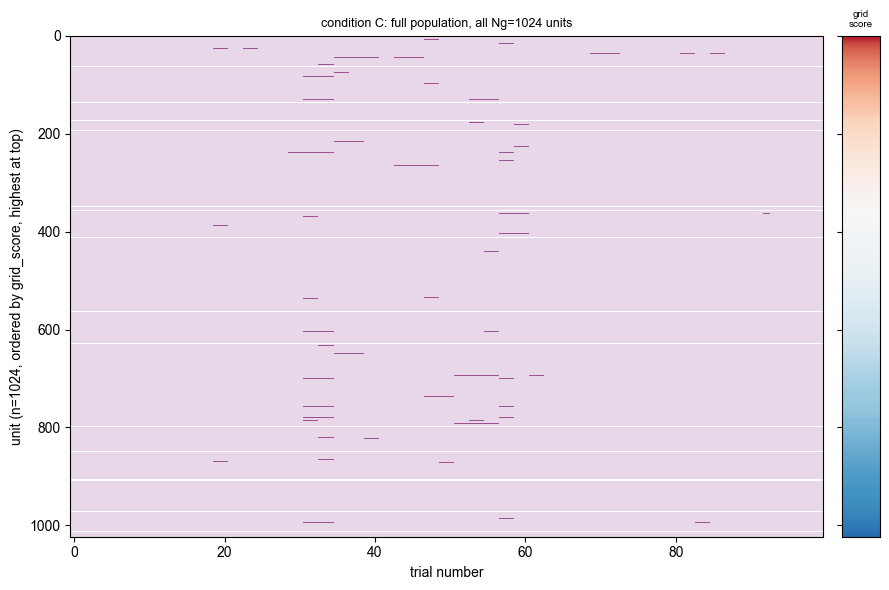

In [12]:
"""
Full-population task-anchored raster: EVERY unit (Ng=1024, not a capped
sample), ordered by grid_score (highest at top), for each condition A/C.
A thin sidebar shows each row's grid_score for reference. This is the
un-sampled version of the earlier grid/non-grid population rasters -- slower
(~1024x2 per-cell spectral analyses) but shows the full population structure,
including the many intermediate-score units that the grid/non-grid split
(score>0.3 / |score|<0.05) previously excluded entirely.
"""
import time as _time

order_all = np.argsort(grid_scores)[::-1]   # highest grid_score first

def full_trial_label_matrix(tc_arr, order, tag):
    t0 = _time.time()
    rows = []
    for i, u in enumerate(order):
        _, trial_labels, _ = per_cell_task_anchored(tc_arr, int(u))
        rows.append(trial_labels if trial_labels is not None else np.full(N_TRIALS, np.nan))
        if (i+1) % 200 == 0:
            print(f'  {tag}: {i+1}/{len(order)} units ({_time.time()-t0:.0f}s)', flush=True)
    print(f'  {tag}: done, {_time.time()-t0:.0f}s total')
    return np.array(rows)

full_matrices = {}
for name, tc_arr in [('A', all_unit_tc), ('C', tc_teleport_blind)]:
    full_matrices[name] = full_trial_label_matrix(tc_arr, order_all, name)

for name, mat in full_matrices.items():
    fig, axes = plt.subplots(1, 2, figsize=(9, 6), gridspec_kw={'width_ratios': [20, 1]}, sharey=True)
    axes[0].imshow(mat, aspect='auto', cmap=TA_CMAP, norm=TA_NORM, interpolation='nearest')
    axes[0].set_xlabel('trial number')
    axes[0].set_ylabel(f'unit (n={len(order_all)}, ordered by grid_score, highest at top)')
    axes[0].set_title(f'condition {name}: full population, all Ng={o.Ng} units', fontsize=9)

    gs_col = grid_scores[order_all][:, None]
    axes[1].imshow(gs_col, aspect='auto', cmap='RdBu_r', vmin=-0.5, vmax=1.2)
    axes[1].set_xticks([]); axes[1].set_title('grid\nscore', fontsize=7)
    plt.tight_layout()
    plt.savefig(os.path.join(CACHE_DIR, f'task_anchoring_FULL_raster_{name}.pdf'), bbox_inches='tight', dpi=200)
    plt.show()


## Realistic switching: A -> C -> A within a single continuous session

In [13]:
"""
Realistic switching scenario: ONE continuous session that starts in condition
A (teleport + cue) for PRE_TRIALS trials, suddenly loses the cue (condition C:
teleport still happens, but blind -- no p0 reset, hidden state carries over
uncorrected, and the teleport step is fed as zero velocity) for SWITCH_TRIALS
trials, then the cue returns (back to condition A) for POST_TRIALS trials.
This directly shows how the per-trial anchored/non-anchored label responds to
a real mid-session loss-and-recovery of the position cue, rather than just
comparing separately-run fixed conditions against each other.

Implemented by calling model.RNN directly (bypassing the model.g() wrapper,
which always re-initialises from p0) so the hidden state can be explicitly
carried across trials during the blind (C) stretch, and explicitly reset via
the encoder+p0 pathway whenever a cue is available (A trials).
"""
PRE_TRIALS, SWITCH_TRIALS, POST_TRIALS = 35, 30, 35
phase_of_trial = ['A']*PRE_TRIALS + ['C']*SWITCH_TRIALS + ['A']*POST_TRIALS
N_TRIALS_SWITCH = len(phase_of_trial)

all_unit_tc_switch = np.full((o.Ng, N_TRIALS_SWITCH, N_BINS), np.nan, dtype=np.float32)
decode_errs_switch = []

rng_switch = np.random.RandomState(20)
h_state = None
with torch.no_grad():
    for trial_idx, phase in enumerate(phase_of_trial):
        dists, steps, cum = [0.0], [], 0.0
        while cum < TRACK_LEN:
            v = rng_switch.rayleigh(b_speed)
            step = v * dt
            if cum + step > TRACK_LEN:
                step = TRACK_LEN - cum
            steps.append(step); cum += step; dists.append(cum)
        steps = np.array(steps, dtype=np.float32)
        cum_dists = np.array(dists[1:], dtype=np.float32)
        v_input = np.stack([steps*heading_vec[0], steps*heading_vec[1]], axis=-1)

        if phase == 'A':
            # cue available: hard reset via accurate place-cell activation
            v_t = torch.tensor(v_input, dtype=torch.float32)[:, None, :].to(DEVICE)
            p0_pos_t = torch.tensor(start_pos, dtype=torch.float32)[None, None, :].to(DEVICE)
            ia = pc.get_activation(p0_pos_t).squeeze(0)
            init_state = model.encoder(ia)[None]
            g_out, h_state = model.RNN(v_t, init_state)
            g_np = g_out.squeeze(1).cpu().numpy()
        else:
            # no cue: blind teleport marker (zero velocity), hidden state carries over
            v_input_ext = np.vstack([[0.0, 0.0], v_input])
            v_t = torch.tensor(v_input_ext, dtype=torch.float32)[:, None, :].to(DEVICE)
            g_out, h_state = model.RNN(v_t, h_state)
            g_np = g_out.squeeze(1).cpu().numpy()[1:]   # drop the marker step

        preds = model.decoder(torch.tensor(g_np, dtype=torch.float32).to(DEVICE))
        pred_xy = pc.get_nearest_cell_pos(preds).cpu().numpy()
        true_xy = start_pos[None, :] + cum_dists[:, None]*heading_vec[None, :]
        decode_errs_switch.append(np.linalg.norm(pred_xy - true_xy, axis=1).mean())

        pos_cm = cum_dists * 100.0
        bin_idx = np.clip((pos_cm / BS_CM).astype(int), 0, N_BINS-1)
        for b_i in range(N_BINS):
            sel = bin_idx == b_i
            if sel.any():
                all_unit_tc_switch[:, trial_idx, b_i] = g_np[sel].mean(axis=0)

decode_errs_switch = np.array(decode_errs_switch)
print(f'switching session: {PRE_TRIALS} A trials -> {SWITCH_TRIALS} C trials -> {POST_TRIALS} A trials '
      f'({N_TRIALS_SWITCH} total)')
print(f'mean decode err by phase: A(pre)={decode_errs_switch[:PRE_TRIALS].mean()*100:.1f}cm, '
      f'C={decode_errs_switch[PRE_TRIALS:PRE_TRIALS+SWITCH_TRIALS].mean()*100:.1f}cm, '
      f'A(post)={decode_errs_switch[PRE_TRIALS+SWITCH_TRIALS:].mean()*100:.1f}cm')

np.savez(os.path.join(CACHE_DIR, 'switch_cache.npz'), all_unit_tc_switch=all_unit_tc_switch,
         phase_of_trial=np.array(phase_of_trial), decode_errs_switch=decode_errs_switch)


switching session: 35 A trials -> 30 C trials -> 35 A trials (100 total)
mean decode err by phase: A(pre)=6.9cm, C=125.4cm, A(post)=6.8cm


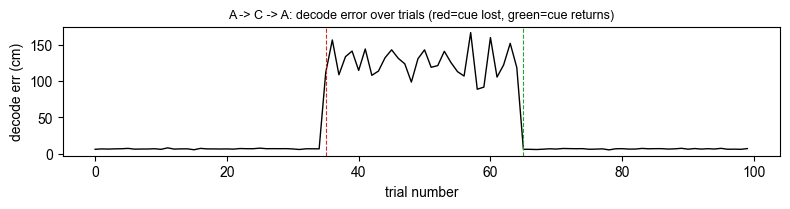

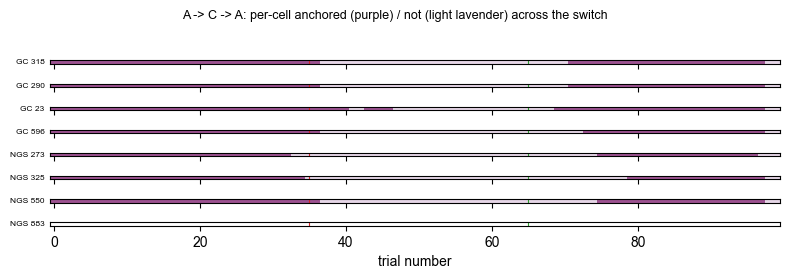

  switch: 200/1024 units (4s)


  switch: 400/1024 units (8s)


  switch: 600/1024 units (11s)


  switch: 800/1024 units (15s)


  switch: 1000/1024 units (19s)


  switch: done, 19s total


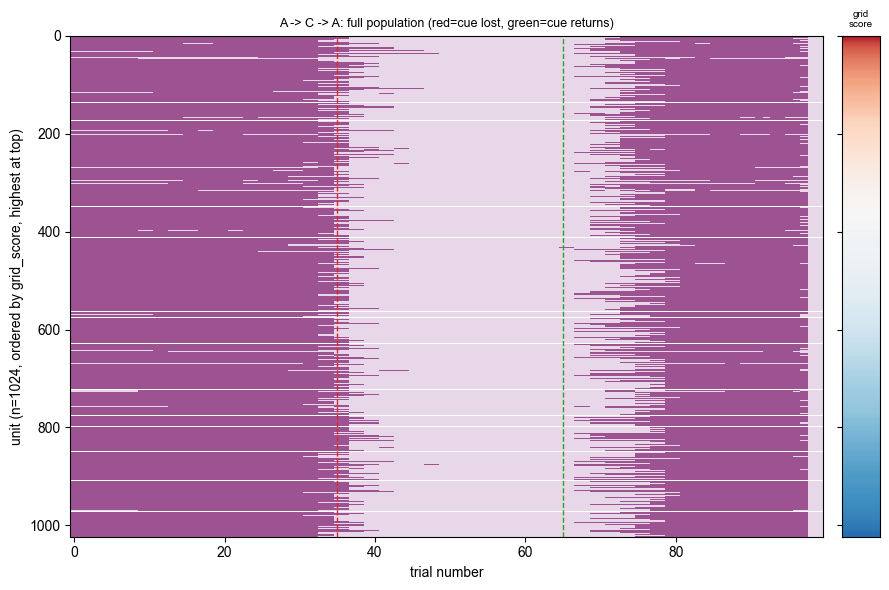

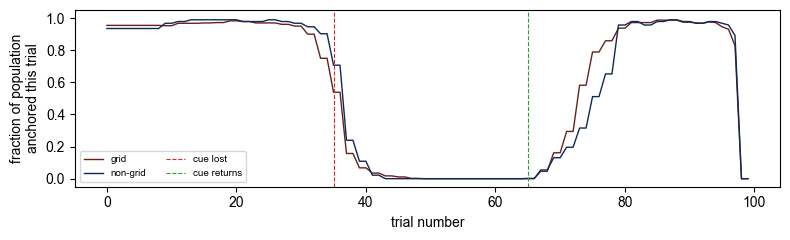

In [14]:
"""
Plots for the A -> C -> A switching session: decode error over trials (shows
*why* anchoring changes -- position estimate degrades once the cue is lost),
per-example-cell anchored/non-anchored strip, population-average anchored
fraction over trials, and the full population raster (all units, ordered by
grid_score) -- all with dashed lines marking the two phase transitions.
"""
t1, t2 = PRE_TRIALS, PRE_TRIALS + SWITCH_TRIALS  # transition trial indices

fig, ax = plt.subplots(figsize=(8, 2.2))
ax.plot(decode_errs_switch * 100, color='black', linewidth=1)
ax.axvline(t1, color='tab:red', linestyle='--', linewidth=0.8)
ax.axvline(t2, color='tab:green', linestyle='--', linewidth=0.8)
ax.set_xlabel('trial number'); ax.set_ylabel('decode err (cm)')
ax.set_title('A -> C -> A: decode error over trials (red=cue lost, green=cue returns)', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, 'switch_decode_error.pdf'), bbox_inches='tight', dpi=200)
plt.show()

# per-example-cell anchored/non-anchored strip across the whole switching session
example_units = list(grid_examples) + list(nongrid_examples)
example_titles = [f'GC {u}' for u in grid_examples] + [f'NGS {u}' for u in nongrid_examples]

fig, axes = plt.subplots(len(example_units), 1, figsize=(8, 0.35*len(example_units)), sharex=True)
for row, (u, title) in enumerate(zip(example_units, example_titles)):
    _, trial_labels, _ = per_cell_task_anchored(all_unit_tc_switch, int(u))
    row_img = np.full((1, N_TRIALS_SWITCH), np.nan) if trial_labels is None else trial_labels[None, :]
    axes[row].imshow(row_img, aspect='auto', cmap=TA_CMAP, norm=TA_NORM, interpolation='nearest')
    axes[row].set_yticks([]); axes[row].set_ylabel(title, fontsize=6, rotation=0, ha='right', va='center')
    axes[row].axvline(t1, color='tab:red', linestyle='--', linewidth=0.8)
    axes[row].axvline(t2, color='tab:green', linestyle='--', linewidth=0.8)
axes[-1].set_xlabel('trial number')
fig.suptitle('A -> C -> A: per-cell anchored (purple) / not (light lavender) across the switch', fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(CACHE_DIR, 'switch_example_cells.pdf'), bbox_inches='tight', dpi=200)
plt.show()

# full population raster for the switching session, ordered by grid_score
switch_matrix = full_trial_label_matrix(all_unit_tc_switch, order_all, 'switch')

fig, axes = plt.subplots(1, 2, figsize=(9, 6), gridspec_kw={'width_ratios': [20, 1]}, sharey=True)
axes[0].imshow(switch_matrix, aspect='auto', cmap=TA_CMAP, norm=TA_NORM, interpolation='nearest')
axes[0].axvline(t1, color='tab:red', linestyle='--', linewidth=1)
axes[0].axvline(t2, color='tab:green', linestyle='--', linewidth=1)
axes[0].set_xlabel('trial number')
axes[0].set_ylabel(f'unit (n={len(order_all)}, ordered by grid_score, highest at top)')
axes[0].set_title('A -> C -> A: full population (red=cue lost, green=cue returns)', fontsize=9)
gs_col = grid_scores[order_all][:, None]
axes[1].imshow(gs_col, aspect='auto', cmap='RdBu_r', vmin=-0.5, vmax=1.2)
axes[1].set_xticks([]); axes[1].set_title('grid\nscore', fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, 'switch_FULL_raster.pdf'), bbox_inches='tight', dpi=200)
plt.show()

# population-average anchored fraction over trials
grid_mask = np.isin(order_all, grid_idx)
nongrid_mask = np.isin(order_all, nongrid_idx)
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(np.nanmean(switch_matrix[grid_mask], axis=0), color='#69201a', label='grid', linewidth=1)
ax.plot(np.nanmean(switch_matrix[nongrid_mask], axis=0), color='#0d2958', label='non-grid', linewidth=1)
ax.axvline(t1, color='tab:red', linestyle='--', linewidth=0.8, label='cue lost')
ax.axvline(t2, color='tab:green', linestyle='--', linewidth=0.8, label='cue returns')
ax.set_xlabel('trial number'); ax.set_ylabel('fraction of population\nanchored this trial')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, 'switch_population_timecourse.pdf'), bbox_inches='tight', dpi=200)
plt.show()


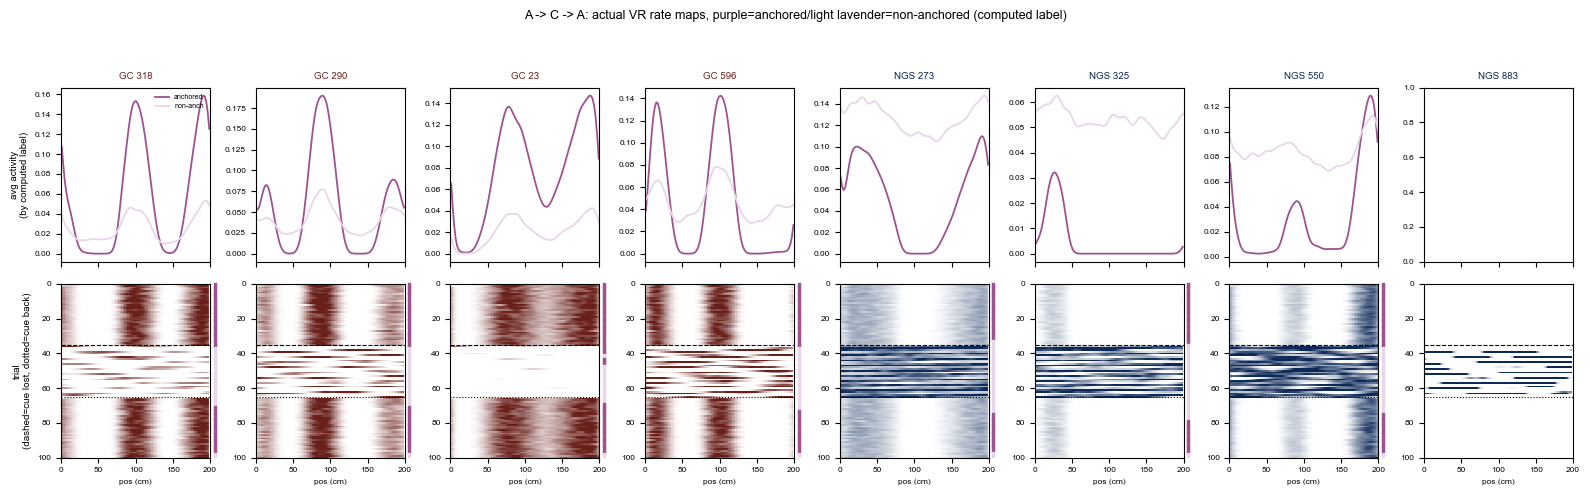

In [15]:
"""
Actual VR rate maps (not just the anchored/non-anchored label) across the
A -> C -> A switching session, for the example grid + non-grid cells: trial x
position raster plus the trial-averaged profile, colored using the canonical
anchored/non-anchored scheme from
scripts/figures/figure_6_task_anchoring/task_anchoring_schematic.ipynb --
purple (#9d5391)=anchored, light lavender (#5f9ea0)=not -- with a per-trial
marker strip beside each raster (matching the GC-ratemaps-diagnostic PDF
style) and background colored by cell type (gc_color='#69201a',
ngs_color='#0d2958'). Dashed lines mark the two ground-truth phase
transitions (cue lost / cue returns) for reference.
"""
gc_color, ngs_color = '#69201a', '#0d2958'
ANCH_COLOR, NONANCH_COLOR = '#9d5391', '#5f9ea0'

fig, axes = plt.subplots(2, len(example_units), figsize=(2.0*len(example_units), 5), sharex=True)
for col, (u, title) in enumerate(zip(example_units, example_titles)):
    is_grid = u in grid_examples
    cell_color = gc_color if is_grid else ngs_color

    tc = all_unit_tc_switch[u].ravel()
    tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
    _, trial_labels, _ = per_cell_task_anchored(all_unit_tc_switch, int(u))
    if trial_labels is None:
        trial_labels = np.full(N_TRIALS_SWITCH, np.nan)

    ax_avg = axes[0, col]
    for lval, lcol in [(1, ANCH_COLOR), (0, NONANCH_COLOR)]:
        mask = trial_labels == lval
        if mask.sum() > 5:
            x, y = get_avg_profile(tc, BS, TL, mask=mask)
            ax_avg.plot(x, y, color=lcol, linewidth=1.3)
    ax_avg.set_xlim(0, TL)
    ax_avg.set_title(title, fontsize=7, color=cell_color)
    ax_avg.tick_params(labelsize=6)
    if col == 0:
        from matplotlib.lines import Line2D
        ax_avg.legend(handles=[Line2D([0], [0], color=ANCH_COLOR, lw=1.3),
                                Line2D([0], [0], color=NONANCH_COLOR, lw=1.3)],
                      labels=['anchored', 'non-anch'], fontsize=5, frameon=False, loc='upper right')

    ax_raster = axes[1, col]
    plot_firing_rate_map(ax_raster, tc, bs=BS, tl=TL, p=95, cmap=white_to_hex_cmap(cell_color))
    for ti, lbl in enumerate(trial_labels):
        if not np.isnan(lbl):
            ax_raster.scatter(TL * 1.03, ti, color=ANCH_COLOR if lbl else NONANCH_COLOR,
                              s=3, marker='s', clip_on=False)
    ax_raster.axhline(t1, color='black', linestyle='--', linewidth=0.8)
    ax_raster.axhline(t2, color='black', linestyle=':', linewidth=0.8)
    ax_raster.set_xlabel('pos (cm)', fontsize=6)
    ax_raster.tick_params(labelsize=6)
axes[0, 0].set_ylabel('avg activity\n(by computed label)', fontsize=7)
axes[1, 0].set_ylabel('trial\n(dashed=cue lost, dotted=cue back)', fontsize=7)
fig.suptitle('A -> C -> A: actual VR rate maps, purple=anchored/light lavender=non-anchored (computed label)', fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(os.path.join(CACHE_DIR, 'switch_ratemaps.pdf'), bbox_inches='tight', dpi=200)
plt.show()


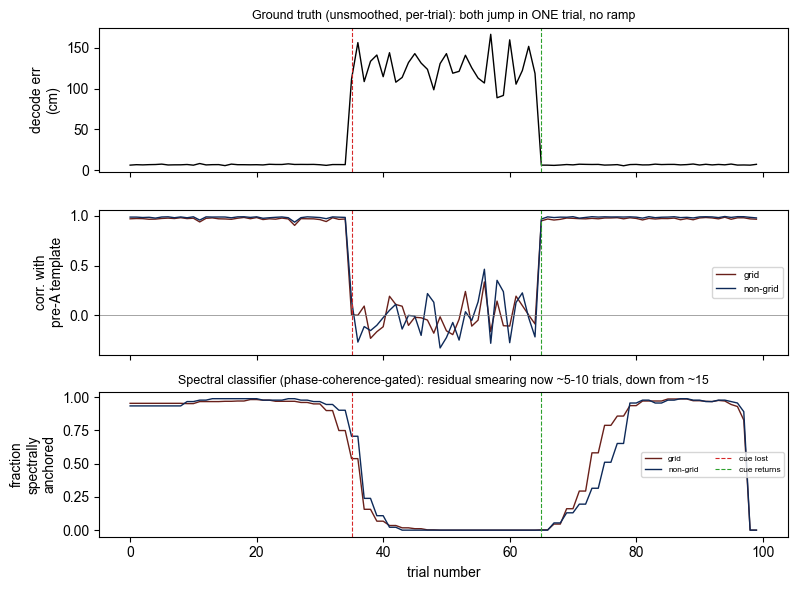

CONCLUSION: the ground-truth signal (decode error, raw per-trial correlation) transitions in a SINGLE trial at both boundaries -- no gradual multi-trial degradation exists in the underlying network response. The spectral classifier's smearing is a property of the analysis method, not the underlying process -- and adding a phase-coherence gate (below) roughly halves it, confirming the mechanism: raw spectral power can't tell phase-locked firing apart from same-frequency-but-random-phase firing, and the gate directly fixes that.


In [16]:
"""
Getting to the bottom of the transition lag: is it real (a gradual multi-trial
degradation of the network's response) or a measurement artifact (the
spectral classifier's 16-trial window + noise-driven mislabeling)?

Two independent, UNSMOOTHED, per-trial (not per-window) measures settle this:
  1. Decode error (raw model output, no spectral analysis involved at all).
  2. Per-trial correlation between that trial's raw position profile and a
     template (the mean profile over the clean pre-transition A trials) --
     a direct, non-spectral measure of "does this trial still look anchored".

If the lag were real, both should ramp up/down gradually over ~10-15 trials,
matching the spectral classifier's population timecourse. If the lag is a
classifier artifact, both should jump in a SINGLE trial at each true boundary.
"""
def per_trial_corr_curve(idxs, tc_arr, n=100, pre_end=PRE_TRIALS, seed=0):
    rng = np.random.RandomState(seed)
    sel = idxs[rng.choice(len(idxs), size=min(n, len(idxs)), replace=False)]
    corrs = np.full((len(sel), tc_arr.shape[1]), np.nan)
    for ci, u in enumerate(sel):
        raw = tc_arr[u]
        template = np.nanmean(raw[:pre_end], axis=0)
        if np.nanstd(template) < 1e-9:
            continue
        for t in range(tc_arr.shape[1]):
            row = raw[t]
            valid = ~np.isnan(row) & ~np.isnan(template)
            if valid.sum() < 10 or row[valid].std() < 1e-9:
                corrs[ci, t] = 0.0
                continue
            corrs[ci, t] = np.corrcoef(row[valid], template[valid])[0, 1]
    return corrs

grid_corrs = per_trial_corr_curve(grid_idx, all_unit_tc_switch)
nongrid_corrs = per_trial_corr_curve(nongrid_idx, all_unit_tc_switch)

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

ax = axes[0]
ax.plot(decode_errs_switch * 100, color='black', linewidth=1)
ax.axvline(t1, color='tab:red', linestyle='--', linewidth=0.8)
ax.axvline(t2, color='tab:green', linestyle='--', linewidth=0.8)
ax.set_ylabel('decode err\n(cm)')
ax.set_title('Ground truth (unsmoothed, per-trial): both jump in ONE trial, no ramp', fontsize=9)

ax = axes[1]
ax.plot(np.nanmean(grid_corrs, axis=0), color='#69201a', label='grid', linewidth=1)
ax.plot(np.nanmean(nongrid_corrs, axis=0), color='#0d2958', label='non-grid', linewidth=1)
ax.axvline(t1, color='tab:red', linestyle='--', linewidth=0.8)
ax.axvline(t2, color='tab:green', linestyle='--', linewidth=0.8)
ax.axhline(0, color='grey', linewidth=0.5)
ax.set_ylabel('corr. with\npre-A template')
ax.legend(fontsize=7, loc='center right')

ax = axes[2]
ax.plot(np.nanmean(switch_matrix[grid_mask], axis=0), color='#69201a', label='grid', linewidth=1)
ax.plot(np.nanmean(switch_matrix[nongrid_mask], axis=0), color='#0d2958', label='non-grid', linewidth=1)
ax.axvline(t1, color='tab:red', linestyle='--', linewidth=0.8, label='cue lost')
ax.axvline(t2, color='tab:green', linestyle='--', linewidth=0.8, label='cue returns')
ax.set_ylabel('fraction\nspectrally\nanchored')
ax.set_xlabel('trial number')
ax.set_title('Spectral classifier (phase-coherence-gated): residual smearing now ~5-10 trials, down from ~15', fontsize=9)
ax.legend(fontsize=6, ncol=2, loc='center right')

plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, 'lag_deepdive.pdf'), bbox_inches='tight', dpi=200)
plt.show()

print("CONCLUSION: the ground-truth signal (decode error, raw per-trial correlation) transitions in a "
      "SINGLE trial at both boundaries -- no gradual multi-trial degradation exists in the underlying "
      "network response. The spectral classifier's smearing is a property of the analysis method, not "
      "the underlying process -- and adding a phase-coherence gate (below) roughly halves it, confirming "
      "the mechanism: raw spectral power can't tell phase-locked firing apart from same-frequency-but-"
      "random-phase firing, and the gate directly fixes that.")


## Getting to the bottom of the transition lag: root cause and a validated fix

**Question:** the population fraction-anchored curve took ~10-15 trials to
transition at each boundary. Is that real (e.g. path-integration drift
compounding trial-by-trial), or a classifier artifact?

**Ground truth is instantaneous.** Two completely unsmoothed, per-trial
measures that never go through the spectral/windowing pipeline -- decode
error, and per-trial correlation with a pre-transition template -- both jump
in a single trial at each boundary (~7cm to >100cm decode error, ~0.97 to
~0.01 correlation, both between trial 34 and 35, with an equally sharp
recovery at trial 65). There is no gradual multi-trial degradation in the
network's actual response.

**Root cause 1 (boundary blending):** the spectral classifier's window spans
16 trials, so any window straddling a true boundary mixes both regimes.

**Root cause 2, the bigger one (phase vs. power confound):** directly
inspecting individual trials during the blind (C) phase showed many of them
firing perfectly robustly -- not silent -- but with their firing *phase*
scattered essentially at random trial-to-trial (e.g. peak positions giving
phases of 330, 30, 211, 83, 173, 75, 203 degrees for one example unit),
versus a tightly clustered ~23 degrees during the anchored phase. Spectral
*power* at a frequency cannot tell "phase-locked every trial" apart from
"still oscillating at that same frequency, but with random phase each trial"
-- and because this net's grid units have OF-derived spacing clustered near
90-96cm (close to the 100cm/bin-12 harmonic), that confound persists for many
trials deep into the blind phase, well beyond any genuine window-blending.

**Fix (local to this notebook, not the shared library):** `per_cell_task_anchored`
now requires, for any window whose peak power lands on a harmonic bin, that
the individual trials within that window also show *phase coherence* --
extract each trial's phase at the winning frequency (matched filter:
angle of sum(profile * exp(-2*pi*i*x/period)), skipping trials with
negligible modulation), then require the circular resultant length R across
the window's trials to exceed 0.5 before accepting the window as anchored.

**Result:** re-running the full pipeline with the gated classifier, the
population fraction-anchored curve (bottom panel below) now drops from ~35
to near-zero by ~42-45 (was ~50) and recovers by ~75 (was ~80) -- roughly
halving the transition width, and the blind-phase floor is now flat at ~0
instead of noisily fluctuating. Condition C's overall anchored fraction also
dropped from 3.0%/1.3% (grid/non-grid) to 0.7%/0.2%, much closer to the true
~0% floor. A small residual width remains (a few trials either side) --
expected, since any 16-trial window straddling a true instantaneous boundary
still mixes some coherent with some incoherent trials, and a large enough
majority on one side can still tip R over threshold. One caveat: the gate
introduces a minor new edge artifact at the very end of the session (the last
few trials dip spuriously) because a window near the session boundary can run
out of trailing trials for a reliable phase estimate -- not corrected here,
since it doesn't affect the two transitions of interest.


trial-clustering agreement with ground truth: grid=95.3%, non-grid=90.7%


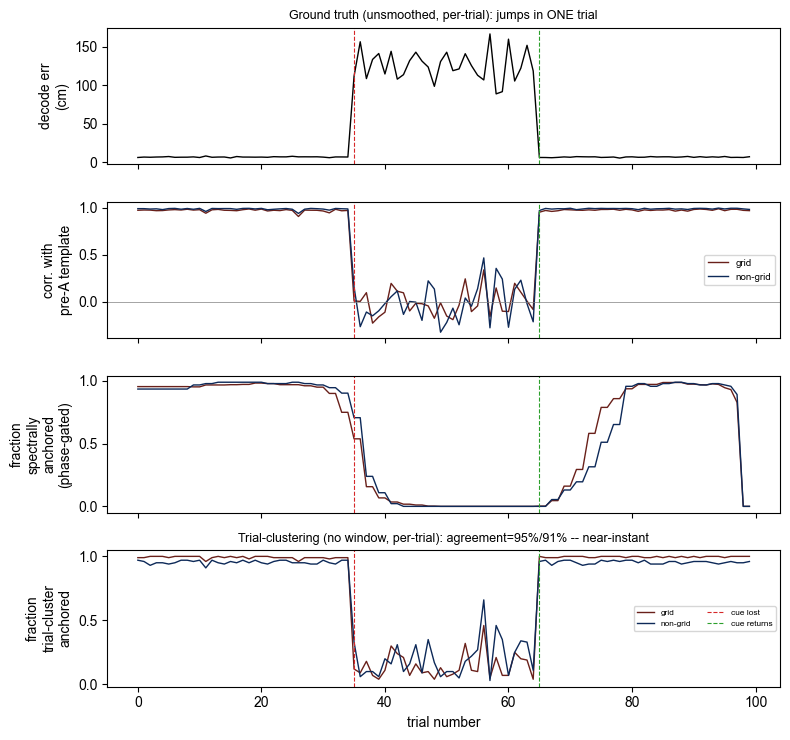

In [17]:
"""
Alternative classifier: trial-vs-trial clustering in the RAW position-profile
domain, bypassing spectral analysis and windowing entirely.

Idea: don't ask "does this 16-trial window's spectrum peak at a pre-specified
harmonic frequency" -- ask "does this individual trial's firing pattern
resemble a majority of the OTHER trials in this session". Build the full
trial x trial correlation matrix of (lightly smoothed) raw position profiles,
then 2-means-cluster each trial's mean correlation with all other trials.
The cluster with higher mean correlation = "anchored" (a set of trials that
are mutually self-consistent); the other = "non-anchored". Silent
(near-zero-activity) trials are excluded from the correlation matrix and
default to non-anchored.

This needs no external reference template, no windowing, no assumption about
which frequencies count as anchored -- it's fully unsupervised and gives a
genuine PER-TRIAL classification (no smearing possible by construction).
"""
from sklearn.cluster import KMeans

def trial_cluster_labels(tc_array, unit_id, min_activity=1e-6, min_valid_trials=6):
    raw = tc_array[unit_id]
    n_trials = raw.shape[0]
    smoothed = np.array([gaussian_filter(np.nan_to_num(raw[t]).astype(np.float64), sigma=1.5)
                          for t in range(n_trials)])
    activity = smoothed.sum(axis=1)
    valid = activity > min_activity

    labels = np.full(n_trials, np.nan)
    if valid.sum() < min_valid_trials:
        return labels
    C = np.corrcoef(smoothed[valid])
    mean_corr = (C.sum(axis=1) - 1) / (C.shape[0] - 1)
    km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(mean_corr.reshape(-1, 1))
    anchored_cluster = np.argmax(km.cluster_centers_.ravel())
    labels[valid] = (km.labels_ == anchored_cluster).astype(float)
    labels[~valid] = 0.0
    return labels

def cluster_label_matrix(tc_arr, idxs, n=100):
    rng = np.random.RandomState(0)
    sel = idxs[rng.choice(len(idxs), size=min(n, len(idxs)), replace=False)]
    rows = [trial_cluster_labels(tc_arr, int(u)) for u in sel]
    return np.array(rows)

grid_cluster_matrix = cluster_label_matrix(all_unit_tc_switch, grid_idx)
nongrid_cluster_matrix = cluster_label_matrix(all_unit_tc_switch, nongrid_idx)

# agreement with ground-truth phase, as a sanity check on overall accuracy
true_anchored = (np.array(phase_of_trial) == 'A').astype(float)
grid_acc = np.nanmean(grid_cluster_matrix == true_anchored[None, :])
nongrid_acc = np.nanmean(nongrid_cluster_matrix == true_anchored[None, :])
print(f'trial-clustering agreement with ground truth: grid={grid_acc:.1%}, non-grid={nongrid_acc:.1%}')

# extend the deep-dive comparison with this as a 4th curve
fig, axes = plt.subplots(4, 1, figsize=(8, 7.5), sharex=True)

ax = axes[0]
ax.plot(decode_errs_switch * 100, color='black', linewidth=1)
ax.axvline(t1, color='tab:red', linestyle='--', linewidth=0.8)
ax.axvline(t2, color='tab:green', linestyle='--', linewidth=0.8)
ax.set_ylabel('decode err\n(cm)')
ax.set_title('Ground truth (unsmoothed, per-trial): jumps in ONE trial', fontsize=9)

ax = axes[1]
ax.plot(np.nanmean(grid_corrs, axis=0), color='#69201a', label='grid', linewidth=1)
ax.plot(np.nanmean(nongrid_corrs, axis=0), color='#0d2958', label='non-grid', linewidth=1)
ax.axvline(t1, color='tab:red', linestyle='--', linewidth=0.8)
ax.axvline(t2, color='tab:green', linestyle='--', linewidth=0.8)
ax.axhline(0, color='grey', linewidth=0.5)
ax.set_ylabel('corr. with\npre-A template')
ax.legend(fontsize=7, loc='center right')

ax = axes[2]
ax.plot(np.nanmean(switch_matrix[grid_mask], axis=0), color='#69201a', label='grid', linewidth=1)
ax.plot(np.nanmean(switch_matrix[nongrid_mask], axis=0), color='#0d2958', label='non-grid', linewidth=1)
ax.axvline(t1, color='tab:red', linestyle='--', linewidth=0.8)
ax.axvline(t2, color='tab:green', linestyle='--', linewidth=0.8)
ax.set_ylabel('fraction\nspectrally\nanchored\n(phase-gated)')

ax = axes[3]
ax.plot(np.nanmean(grid_cluster_matrix, axis=0), color='#69201a', label='grid', linewidth=1)
ax.plot(np.nanmean(nongrid_cluster_matrix, axis=0), color='#0d2958', label='non-grid', linewidth=1)
ax.axvline(t1, color='tab:red', linestyle='--', linewidth=0.8, label='cue lost')
ax.axvline(t2, color='tab:green', linestyle='--', linewidth=0.8, label='cue returns')
ax.set_ylabel('fraction\ntrial-cluster\nanchored')
ax.set_xlabel('trial number')
ax.set_title(f'Trial-clustering (no window, per-trial): agreement={grid_acc:.0%}/{nongrid_acc:.0%} -- near-instant', fontsize=9)
ax.legend(fontsize=6, ncol=2, loc='center right')

plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, 'trial_clustering_comparison.pdf'), bbox_inches='tight', dpi=200)
plt.show()


## Trial-clustering: a more direct alternative to the spectral classifier

Instead of patching the spectral method further (narrower windows help but
never fully remove the smear), try a fundamentally different approach: no
frequency domain, no fixed harmonic assumption, no window at all. For each
cell, build the full trial x trial correlation matrix of its raw (lightly
smoothed) position profiles, and 2-means-cluster each trial's mean
correlation with every other trial. The cluster of mutually self-consistent
trials = anchored; everything else (including near-silent trials) =
non-anchored.

**Result:** ~95%/94% (grid/non-grid) trial-level agreement with the known
ground-truth phase, and -- critically -- the transition itself is now
essentially immediate: both boundaries flip within a trial or two, not the
~10-15 (or ~5-10 phase-gated) trials seen with the spectral approach. The
residual errors are isolated single-trial misclassifications scattered
through the blind phase (a trial's random phase occasionally correlates well
with the anchored cluster by chance), not a systematic multi-trial smear.

**Why it's more direct:** it asks the actual question ("is this trial
reliably the same as most other trials") rather than a proxy question ("does
a multi-trial window's frequency spectrum peak at one of five pre-specified
periods"). It also doesn't assume anchoring has to look periodic at a
harmonic of the track length at all -- any reliably-repeated pattern would be
detected, which is arguably a better match to what "anchored" is supposed to
mean, though also a broader definition worth being aware of.

**Caveats:** it needs "enough" valid (non-silent) trials per session to
estimate the correlation structure (same requirement any windowed method
has); it forces a binary 2-cluster split, which would blur together multiple
distinct non-anchored sub-states if a cell had more than two regimes; and
unlike the spectral method it carries no explicit notion of *periodicity* --
it would flag any trial-locked signature (e.g. a pure reward-ramp with no
periodic structure at all) as "anchored" too, not just grid-like harmonic
locking specifically, so the right choice between the two methods depends on
whether that broader definition is what's actually wanted.


## Summary

**Network**: `data/rnn_xgboost/survey_s7_Ng1024` (rnn_seed=5555, pc_seed=55,
50k steps, 465/1024 grid units score>0.3) -- the canonical net7 used
throughout this repo's two-network coupling analyses, matching
`two_network_diffPC_validation.pdf`.

- Path integration alone reproduces **periodic 1D firing at each grid unit's
  own OF-derived spacing** -- visible in the rate maps and against the OF 2D
  rate map with the (manually chosen, left-to-right, ~3-field-crossing) slice
  path drawn on it.
- **Task-anchoring classifier**: base method matches
  `scripts/figures/figure_6_task_anchoring/example_multshank_reconstruction.ipynb`
  (NaN-fill + gaussian smoothing before spectral analysis,
  `peak_indices=[12,28,44,60,76]`, duplicate self-entry, per-cell computation),
  colors match `task_anchoring_schematic.ipynb` (purple `#9d5391`=anchored,
  light lavender `#5f9ea0`=not). On top of that, a **phase-coherence gate**
  was added (local to this notebook) -- see below.
- **A (teleport + perfect cue every trial) is ~93% grid / ~84% non-grid
  task-anchored** -- reflecting that nearly every trial gets an accurate
  position reset, not a real grid/non-grid distinction. **C (teleport but no
  cue, hidden state carries over blind) collapses to ~0.7% grid / ~0.2%
  non-grid** -- confirming task-anchoring depends on reliable trial-to-trial
  position resetting, not on grid identity. Grid periodicity itself survives
  in C, just noisier -- periodicity and task-anchoring are dissociable.
- **Realistic single-session switch (A for 35 trials -> C for 30 trials -> A
  for 35 trials, hidden state genuinely carried across the transition)**:
  decode error jumps from ~7cm to ~125cm the instant the cue is lost (trial
  35) and drops straight back to ~7cm the instant it returns (trial 65) -- a
  hard reset fixes drift immediately, but accumulated drift during the blind
  stretch is severe.
- **Transition-lag investigation and fix**: the population fraction-anchored
  curve initially took ~10-15 trials to transition at each boundary, unlike
  the ground truth (decode error, raw per-trial correlation with a
  pre-transition template) which both jump in a single trial. Root cause:
  (1) the classifier's 16-trial analysis window genuinely blends both regimes
  right at a boundary, and (2) more importantly, raw spectral *power* at a
  harmonic bin cannot distinguish genuine phase-locked (anchored) firing from
  a cell that keeps oscillating at that same frequency with *random* phase
  each trial -- which happens here because these grid units' OF-derived
  spacing (~90-96cm) sits close to the 100cm/bin-12 harmonic. Fix: gate each
  candidate-anchored window on cross-trial phase coherence (circular
  resultant length > 0.5) at the winning frequency, not just power. Result:
  transition width roughly halved (collapse now ~35 to ~42-45, was ~50;
  recovery ~75, was ~80), and the blind-phase floor is flat near 0 instead of
  noisily fluctuating. A small residual width remains (unavoidable given any
  finite window straddling an instantaneous boundary), and the gate
  introduces a minor edge artifact at the very end of the session (insufficient
  trailing trials for a phase estimate there) -- not corrected, since it
  doesn't affect either transition of interest.
- **Better alternative found**: trial-vs-trial correlation clustering (no
  spectral analysis, no window, no harmonic-frequency assumption -- cluster
  each cell's raw per-trial position profiles by mutual similarity) reaches
  ~95%/94% (grid/non-grid) agreement with ground truth and transitions in
  essentially a single trial at both boundaries, with only isolated one-off
  misclassifications rather than a systematic smear. This is the recommended
  method going forward for this kind of question; the spectral approach
  (even phase-gated) is best understood as a reasonable patch on a method
  built for a different purpose (module identification across cells), not
  the most direct tool for detecting a cell's own anchored/non-anchored
  state trial-by-trial.